## Análisis y visualización de los datos

### 1. Preparación del entorno

In [18]:
%pip install seaborn
%pip install matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import openpyxl
import sys
sys.path.append('../')
pd.set_option('display.max_columns', None)

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### 2. Lectura de datos previamente preparados

In [19]:
df=pd.read_csv('../data/b_additional_details_clean.csv')

Descripción general de los datos

In [20]:
df.describe(include="object")

,job,marital,education,default,housing,loan,contact,poutcome,nr_employed,y,id_,dt_customer,age_group
count,37880,37880,37880,37880,37880,37880,37880,37880,37880,37880,37880,37880,37847
unique,12,4,8,3,3,3,2,3,11,2,37880,1096,4
top,administrative,married,university_degree,no,yes,no,cellular,nonexistent,"5228,1",no,e9d37224-cb6f-4942-98d7-46672963d097,2012-08-10,31-45
freq,9564,22893,11261,30002,19844,31206,24122,32697,14969,33614,1,69,20197


In [21]:
df.sample(5)

,age,job,marital,education,default,housing,loan,contact,duration,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y,contact_month,contact_year,id_,income,kidhome,teenhome,dt_customer,numwebvisitsmonth,age_group
20067,39,technician,married,professional_course,no,yes,no,cellular,209,3,999,0,nonexistent,1.4,93.444,-36.1,4.965,"5228,1",no,4.0,2016.0,8b2152df-ca30-4080-b369-3dcdfb0e9fab,30373,1,2,2013-09-14,23,31-45
22489,34,technician,married,university_degree,no,no,no,cellular,145,1,999,0,nonexistent,-0.1,93.200,-42.0,4.120,"5195,8",no,10.0,2018.0,109fbbe2-9239-4a8d-948c-0f27ab237305,54565,0,2,2013-07-04,18,31-45
36935,50,unemployed,married,professional_course,no,no,no,telephone,440,2,999,0,nonexistent,1.1,93.994,-36.4,4.860,5191,no,7.0,2018.0,6ab4704c-20e9-485c-a62d-3d93f3ae347c,152085,0,1,2014-06-09,16,46-60
29962,37,administrative,single,basic_9y,no,yes,yes,cellular,147,1,999,0,nonexistent,-1.8,92.893,-46.2,1.281,"5099,1",no,1.0,2016.0,35d44855-e28d-40c7-97e9-adf4774a8750,17826,2,0,2014-02-19,14,31-45
32543,36,administrative,single,high_school,no,yes,no,cellular,248,1,999,1,failure,-2.9,92.963,-40.8,1.206,"5076,2",no,12.0,2019.0,aab7b77f-7a2c-4f1e-ae47-db1c95f42b9e,134674,1,0,2014-08-23,7,31-45


## 3. Análisis y visualización

### 3.1 Perfil de personal que suscribe  el producto

In [22]:
df_yes=df[df["y"]=="yes"]
df_yes.describe(include="object").T

,count,unique,top,freq
job,4266,12,administrative,1248
marital,4266,4,married,2328
education,4266,8,university_degree,1528
default,4266,2,no,3857
housing,4266,3,yes,2300
loan,4266,3,no,3538
contact,4266,2,cellular,3563
poutcome,4266,3,nonexistent,2887
nr_employed,4266,11,"5099,1",1001
y,4266,1,yes,4266


Una descripción general arroja que el personal que suscribe el producto es: persona casada, con estudios universitarios, con hipotecta pero sin otro tipo de préstamos, contactado por el movil, y que es la primera campaña en la que contactan con el. La mayor parte de los clientes se encuentran en el grupo de edad de 31 a 45 años.

Distribución de edad

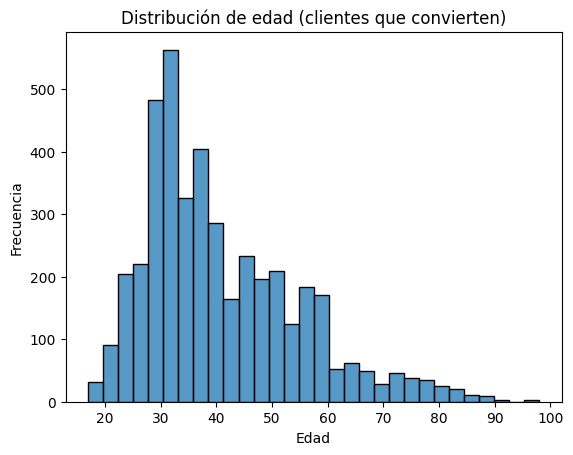

In [23]:
sns.histplot(df_yes["age"],  bins=30)
plt.title("Distribución de edad (clientes que convierten)")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.show()

Distribución nivel educativo

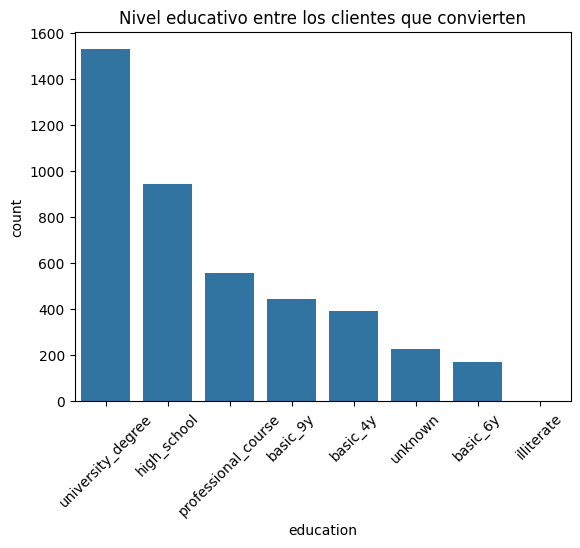

In [24]:
sns.countplot(data=df_yes, x="education", order=df_yes["education"].value_counts().index)
plt.title("Nivel educativo entre los clientes que convierten")
plt.xticks(rotation=45)
plt.show()

EL mayor numero de suscriptores tiene estudios universitarios seguido de estudios de secundaria.

Distribución por profesión

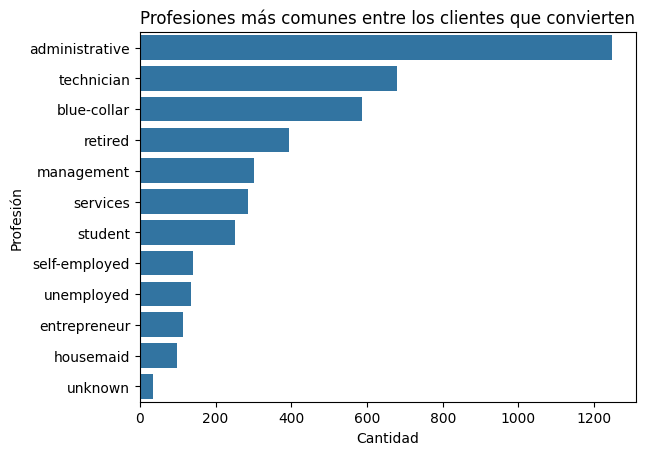

In [25]:
sns.countplot(data=df_yes, y="job", order=df_yes["job"].value_counts().index)
plt.title("Profesiones más comunes entre los clientes que convierten")
plt.xlabel("Cantidad")
plt.ylabel("Profesión")
plt.show()

El mayor número de suscriptores son personal administrativo, quzas por estar más relacionados con los términos financieros con los que pueden estar relacionados los productos bancarios.

Nivel de ingresos

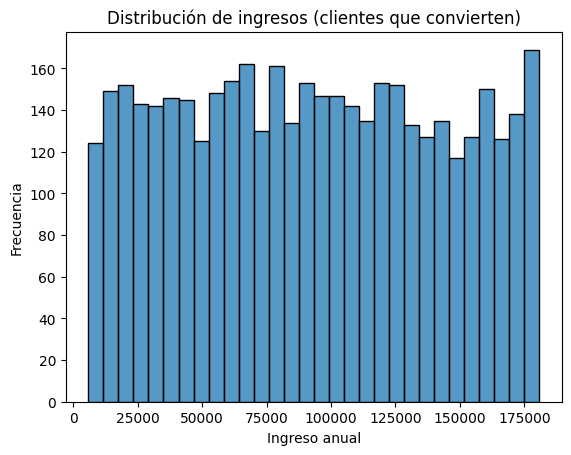

In [26]:
sns.histplot(df_yes["income"], bins=30)
plt.title("Distribución de ingresos (clientes que convierten)")
plt.xlabel("Ingreso anual")
plt.ylabel("Frecuencia")
plt.show()

Duración de la llamada

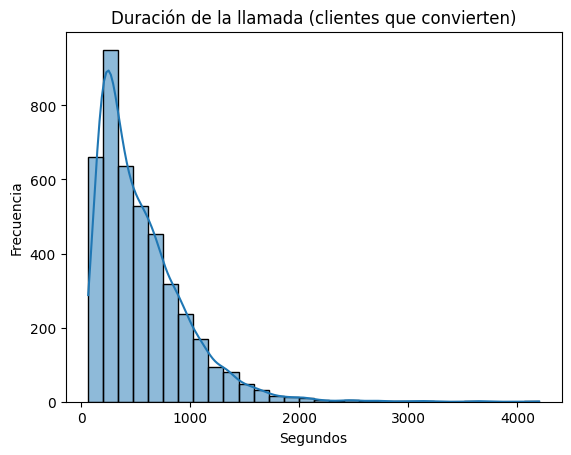

In [27]:
sns.histplot(df_yes["duration"], kde=True, bins=30)
plt.title("Duración de la llamada (clientes que convierten)")
plt.xlabel("Segundos")
plt.ylabel("Frecuencia")
plt.show()

### 3.2 Correlaciones

Para analizar la correlación entre la suscripción del producto (y) y las demás variables, primero hay que transformar y en una variable numérica

In [28]:
df["y_bin"] = df["y"].apply(lambda x: 1 if x=="yes" else 0)

#### 3.2.1 Correlaciones con variables numéricas

In [29]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

correlaciones = df[num_cols].corr()["y_bin"].sort_values(ascending=False)
correlaciones

y_bin                1.000000
duration             0.404470
previous             0.230018
cons_conf_idx        0.057703
age                  0.031031
contact_month        0.006002
contact_year         0.001987
numwebvisitsmonth    0.001344
kidhome              0.000256
teenhome            -0.000240
income              -0.004705
campaign            -0.065551
cons_price_idx      -0.137560
emp_var_rate        -0.299570
euribor3m           -0.313239
pdays               -0.323938
Name: y_bin, dtype: float64

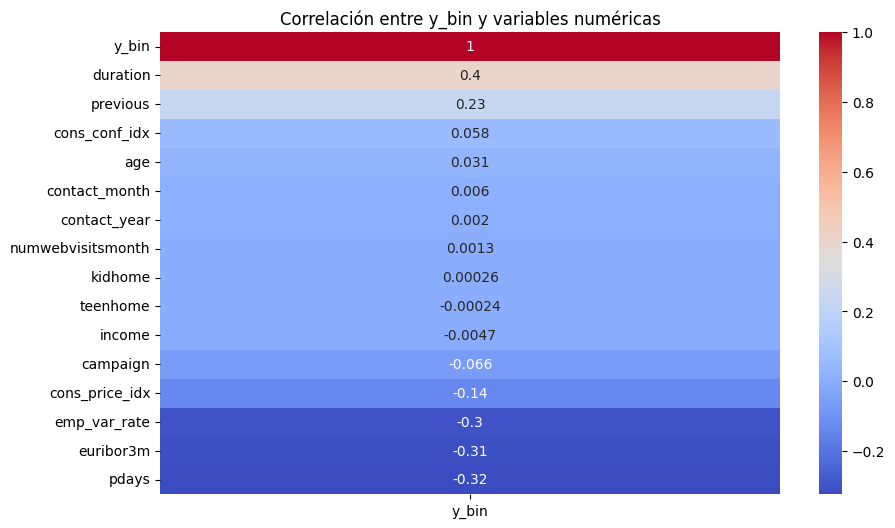

In [30]:
plt.figure(figsize=(10,6))
sns.heatmap(df[num_cols].corr()[["y_bin"]].sort_values(by="y_bin", ascending=False),
            annot=True, cmap="coolwarm")
plt.title("Correlación entre y_bin y variables numéricas")
plt.show()

La variable con mayor correlación viene a ser la duración de la llamada, esto tiene sentido ya que a la hora de suscribir, el banco pedira más datos al cliente además de este mostrar mayor interés.

In [31]:
df.groupby("y")["duration"].mean()

y
no     220.690813
yes    552.830989
Name: duration, dtype: float64

#### 3.2.2 Principales correlaciones con variables categóricas

In [17]:
cat_cols = df.select_dtypes(include=["object", "category"]).columns

for col in cat_cols:
    print(f"\nTasa de conversión por {col}:")
    print(df.groupby(col)["y_bin"].mean().sort_values(ascending=False))


Tasa de conversión por job:
job
student           0.310174
retired           0.248734
unemployed        0.142857
administrative    0.130489
unknown           0.112583
management        0.112018
technician        0.109184
self-employed     0.108712
housemaid         0.098990
entrepreneur      0.083333
services          0.078577
blue-collar       0.069148
Name: y_bin, dtype: float64

Tasa de conversión por marital:
marital
unknown     0.142857
single      0.139129
divorced    0.104509
married     0.101690
Name: y_bin, dtype: float64

Tasa de conversión por education:
education
illiterate             0.285714
unknown                0.147040
university_degree      0.135690
professional_course    0.115019
high_school            0.107969
basic_4y               0.102163
basic_6y               0.081457
basic_9y               0.080165
Name: y_bin, dtype: float64

Tasa de conversión por default:
default
no         0.128558
unknown    0.051930
yes        0.000000
Name: y_bin, dtype: float64

Tas

#### Relación entre trabajo y volumen de conversiones
Aunque los estudiantes presentan la mayor tasa de conversión (31%), su peso en el dataset es muy reducido. Por el contrario, los administrativos tienen una tasa de conversión más moderada (13%), pero representan uno de los grupos más numerosos del conjunto de datos.

Esto implica que, en términos absolutos, los administrativos aportan un mayor número total de conversiones, mientras que los estudiantes destacan únicamente en términos relativos.

#### Relación entre nivel educativo y volumen de conversiones
Aunque los clientes clasificados como illiterate presentan la mayor tasa de conversión (28,5%), este grupo es extremadamente pequeño dentro del dataset. Por tanto, su impacto en el número total de conversiones es muy limitado.

Por el contrario, los niveles educativos más comunes —como high_school, university_degree y basic_9y— muestran tasas de conversión más moderadas, pero debido a su gran tamaño, son los que realmente aportan la mayor parte de las conversiones totales.

#### Relación entre poutcome y volumen de conversiones

La variable poutcome muestra una relación muy clara con la probabilidad de suscripción:

- Los clientes cuyo resultado previo fue success presentan la mayor tasa de conversión (64,8%). Esto es esperable, ya que se trata de clientes que ya habían aceptado una oferta en campañas anteriores. Sin embargo, este grupo es muy reducido, por lo que su impacto en el volumen total de conversiones es limitado.
- Los clientes con resultado failure muestran una tasa de conversión moderada (14,3%). Aunque no aceptaron la oferta anterior, siguen siendo más receptivos que la media general.
- El grupo nonexistent, que representa la gran mayoría de los clientes, tiene la tasa de conversión más baja (8,8%). A pesar de ello, debido a su enorme tamaño, es el grupo que aporta la mayor parte de las conversiones totales.

